# Exploratory Data Analysis Report

## Objective
The objective of this analysis is to explore customer transaction data,
identify patterns, understand relationships between variables,
and generate business insights to support decision-making.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\Users\HP\Desktop\project imar\customer data\cleaned_dataset.csv")
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Day,Weekday
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,8,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,23,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,10,5,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False,2022,5,7,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,2,Sunday


In [5]:
df.shape

(11971, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11971 entries, 0 to 11970
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    11971 non-null  object 
 1   Customer ID       11971 non-null  object 
 2   Category          11971 non-null  object 
 3   Item              11971 non-null  object 
 4   Price Per Unit    11971 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    11971 non-null  object 
 8   Location          11971 non-null  object 
 9   Transaction Date  11971 non-null  object 
 10  Discount Applied  11971 non-null  bool   
 11  Year              11971 non-null  int64  
 12  Month             11971 non-null  int64  
 13  Day               11971 non-null  int64  
 14  Weekday           11971 non-null  object 
dtypes: bool(1), float64(3), int64(3), object(8)
memory usage: 1.3+ MB


## Dataset Overview
- Number of rows: 11911
- Number of columns: 15
- Numerical features: - Price Per Unit
                      - Quantity
                      - Total Spent

- Categorical features: - Category
                        - Payment Method
                        - Location
                        - Weekday
The dataset represents retail customer transactions used to analyze
spending behavior and revenue drivers.

In [7]:
numerical_col=["Price Per Unit","Quantity","Total Spent"]
df[numerical_col].describe()

,Price Per Unit,Quantity,Total Spent
count,11971.000000,11971.000000,11971.000000
mean,23.360872,5.536380,129.652577
std,10.741889,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


## Descriptive Statistics Insights

- Average spending per transaction indicates typical customer value.
- Maximum values reveal presence of high-value purchases.
- Distribution spread suggests variability in customer behavior.

In [8]:
categorical_col=["Category","Payment Method","Location","Weekday"]
df[categorical_col].describe()

,Category,Payment Method,Location,Weekday
count,11971,11971,11971,11971
unique,8,3,2,7
top,Furniture,Cash,Online,Sunday
freq,1525,4103,6068,1736


In [9]:
df["Payment Method"].value_counts()

Payment Method
Cash              4103
Digital Wallet    3941
Credit Card       3927
Name: count, dtype: int64

In [10]:
df["Category"].unique()

array(['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food',
       'Furniture', 'Electric household essentials',
       'Computers and electric accessories'], dtype=object)

## Univariate Analysis
This section analyzes individual variable distributions to detect
skewness, outliers, and dominant categories.

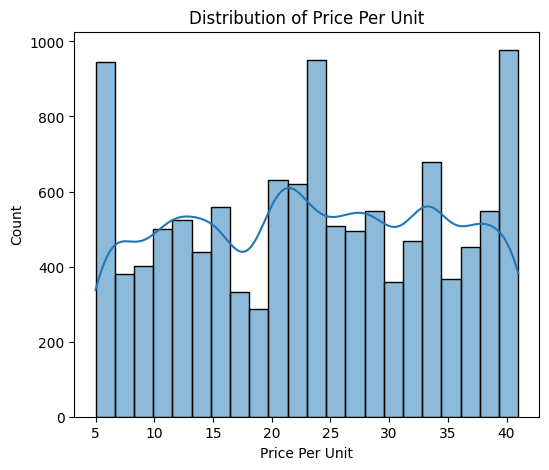

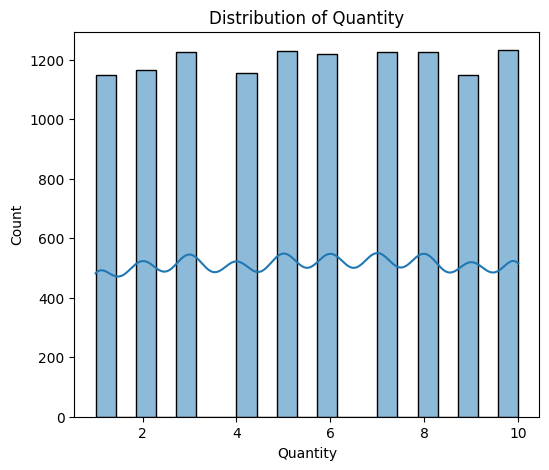

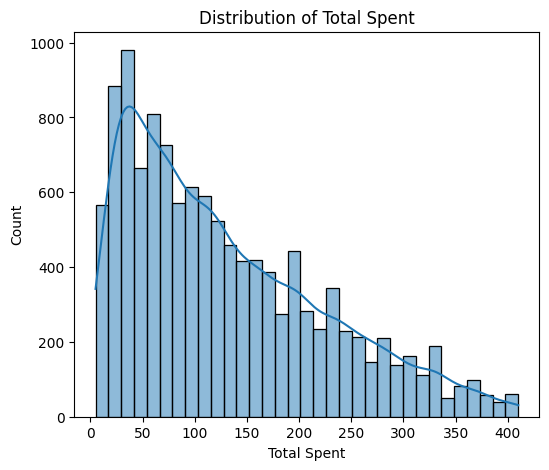

In [11]:
for col in numerical_col:
    plt.figure(figsize=(6,5))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Most transactions involve small quantities and lower-priced items, indicating typical low-value purchases. 
### Insight — Price Per Unit Distribution
The price distribution is relatively spread across the available range, indicating a diverse product pricing strategy.
### Insight — Quantity Distribution
Purchase quantities appear evenly distributed across values,
indicating customers buy in varied amounts rather than showing
strong preference toward a specific quantity level.
### Insight — Total Spent Distribution
Total spending shows a right-skewed distribution where most
transactions are low-value, while fewer high-value purchases
extend the tail.

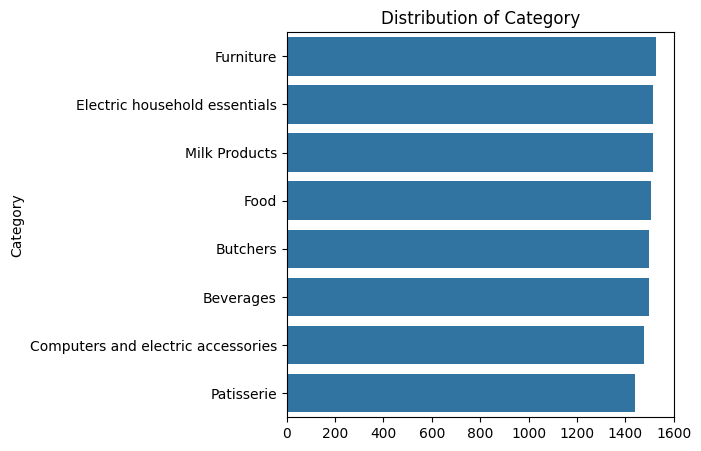

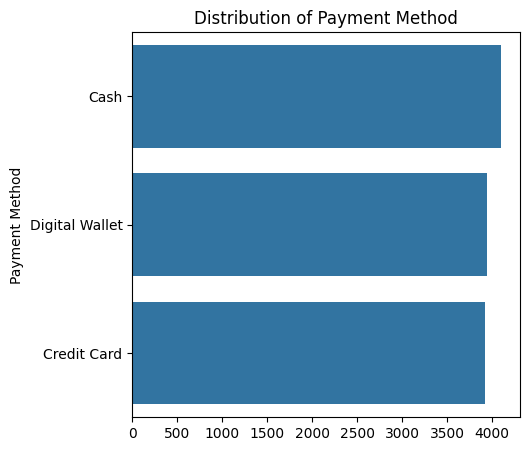

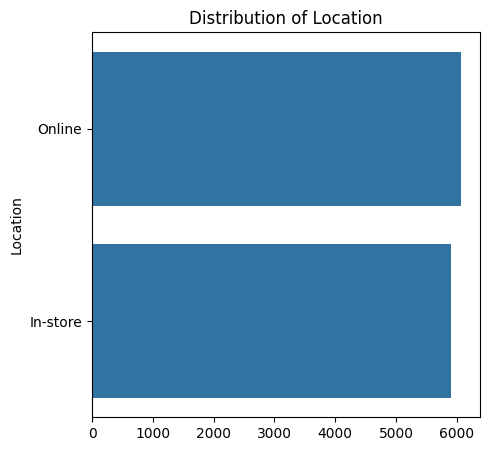

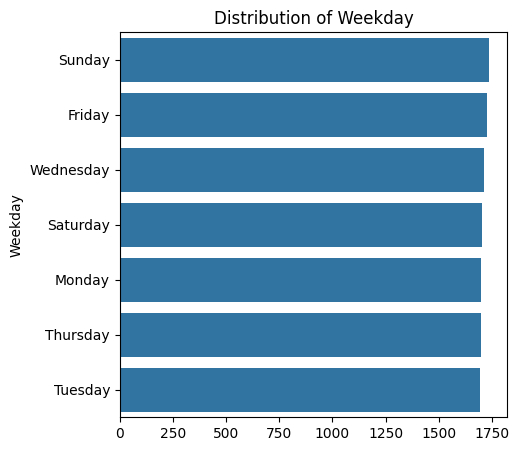

In [12]:
for col in categorical_col:
    plt.figure(figsize=(5,5))
    counts=df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index,orient='h')
    plt.title(f"Distribution of {col}")
    plt.show()

### Insight — Category Distribution
Transaction counts are relatively balanced across product categories, suggesting diversified customer demand ranther than reliance on single segment.
### Insight — Payment Preferences
Payment method is evenly distributed between cash,digital wallet and credit card, indicating customers are comfortable using multiple channels.
### Insight — Sales Channel Activity
Online and in-store transactions occur at comparable levels, demonstrating successful omnichannel engagement.

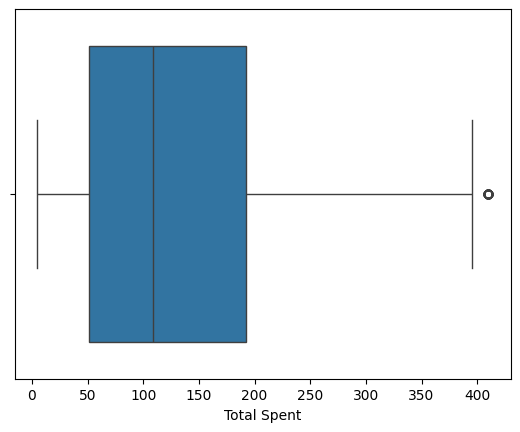

In [13]:
sns.boxplot(x=df["Total Spent"])
plt.show()

In [14]:
df["Year"].value_counts()

Year
2024    4036
2022    3925
2023    3808
2025     202
Name: count, dtype: int64

## Multivariate Analysis
Exploring relationships between multiple variables to detect patterns,
correlations, and behavioral trends.

Text(0.5, 1.0, 'Scatter Plot of Total Spent vs Price Per Unit')

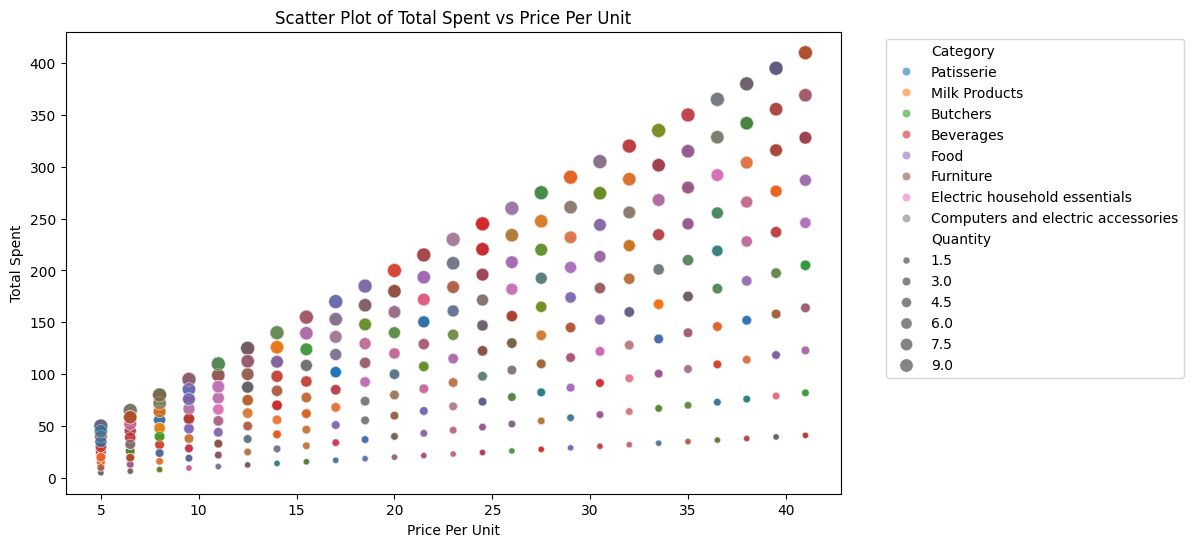

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Price Per Unit",y="Total Spent",hue="Category",size="Quantity",sizes=(20,100),alpha=0.6,data=df)
plt.legend(bbox_to_anchor=(1.05,1),loc="upper left")
plt.title("Scatter Plot of Total Spent vs Price Per Unit")

### Insight — Spending Relationship
The scatter plot shows total spending increasing with price per unit,
and marker size indicates higher quantities further amplify spending.
This highlights that both price and purchase volume jointly

In [16]:
corr= df[numerical_col].corr()

Text(0.5, 1.0, 'Correlation Heatmap')

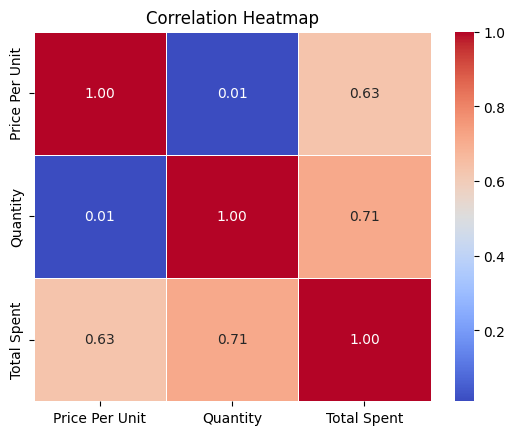

In [17]:
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")

### Insight — Correlation Analysis
Quantity and Total Spent exhibit strong positive correlation,
confirming that larger purchase volumes significantly increase
transaction value. Price Per Unit also shows moderate correlation
with Total Spent, indicating pricing contributes to revenue but
volume remains the dominant driver.

Text(0.5, 1.02, 'Pair plot of numerical variables')

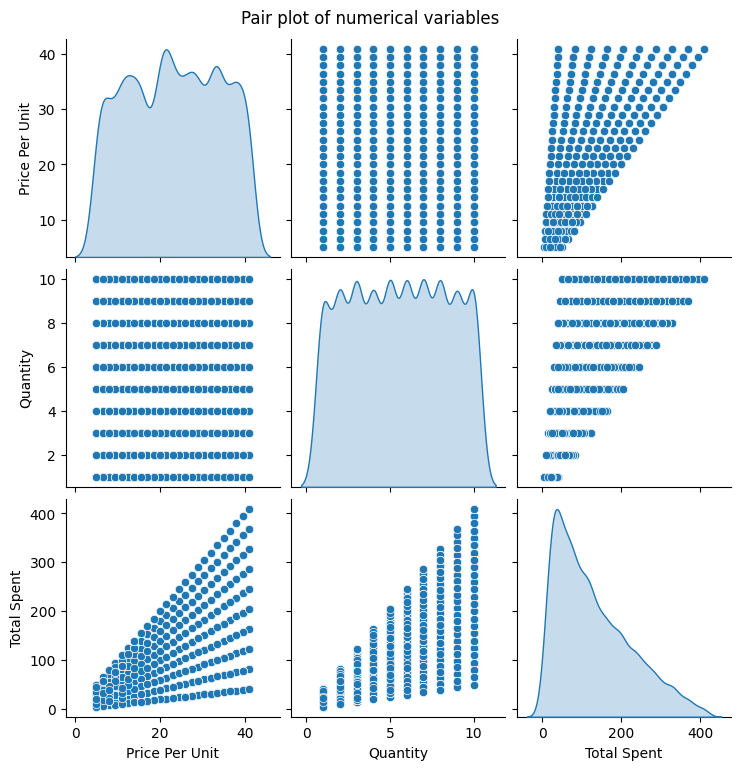

In [18]:
sns.pairplot(data=df[numerical_col],kind="scatter",diag_kind="kde")
plt.suptitle("Pair plot of numerical variables",y=1.02)

### Insight — Pair Plot
Pairwise comparisons confirm spending increases with quantity
and reveal clusters of different transaction values.

## SQL Business Insights

Analysis of SQL queries revealed:

- Certain products generate the highest revenue
- Specific locations outperform others in sales
- A small group of customers contribute significantly
- Monthly revenue trends show seasonal variation
- Payment method preferences highlight user behavior

## Recommendations

- Focus marketing on high-performing products
- Retain top customers through loyalty programs
- Expand strategies in high-revenue locations
- Monitor monthly trends for inventory planning

## Conclusion
EDA uncovered important patterns in customer spending,
product performance, and geographic sales distribution.
These insights can guide KPI tracking and business strategy.